#**스마트폰 센서 데이터 기반 모션 분류**
# 단계1 : 탐색적 데이터 분석

## 0.미션

### (1) 미션1
수많은 feature들을 모두 살펴보는 것은 과도한 시간과 노력이 필요합니다. 그래서 여러분은 **선택과 집중**을 해야 합니다.
* 1) **기본 모델을 생성**한 후 **변수 중요도**를 구합니다.   
    * random forest 알고리즘 사용을 권장합니다.
* 2) **중요한 feature와 중요하지 않은 feature 상위 N개를 선정**하고, 이들을 대상으로 EDA 수행.


### (2) 미션2
다음의 case에 맞게 feature 및 feature 그룹 중요도를 기반으로 탐색적 데이터 분석을 수행하시오.
* Target을 **정적/동적 행동**으로 구분
    * 6개의 행동은 2개의 그룹(정적행동, 동적행동)으로 나뉩니다.  
    * 어떤 feature(혹은 feature 그룹)이 2개 class 그룹(정적행동, 동적행동)를 구분하는데 중요한지를 찾아보고 탐색해봅시다.


## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
path = '/content/drive/MyDrive/Deep_Learning/project3/'

### (2) 라이브러리 설치 및 불러오기

* 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

* 제공 함수 생성
    * 변수 중요도를 시각화할 수 있는 함수를 제공합니다.
    * 입력 :
        * importance : 트리모델의 변수 중요도(예: model.feature_importances_)
        * names : 변수 이름 목록(예 : x_train.columns
        * result_only  : 변수 중요도 순으로 데이터프레임만 return할지, 그래프도 포함할지 결정. False이면 결과 데이터프레임 + 그래프
        * topn : 중요도 상위 n개만 표시. all 이면 전체.
    * 출력 :
        * 중요도 그래프 : 중요도 내림차순으로 정렬
        * 중요도 데이터프레임 : 중요도 내림차순으로 정렬

In [ ]:
# 변수의 특성 중요도 계산하기
def plot_feature_importance(importance, names, result_only = False, topn = 'all'):
    feature_importance = np.array(importance)
    feature_name = np.array(names)

    data={'feature_name':feature_name,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    #변수의 특성 중요도 순으로 정렬하기
    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    #변수의 특성 중요도 그래프로 그리기
    if result_only == False :
        plt.figure(figsize=(10,20))
        sns.barplot(x='feature_importance', y='feature_name', data = fi_df)

        plt.xlabel('importance')
        plt.ylabel('feature name')
        plt.grid()

    return fi_df

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

In [ ]:
train_data = pd.read_csv(path + 'data01_train.csv')
test_data = pd.read_csv(path + 'data01_test.csv')
feature_data = pd.read_csv(path + 'features.csv')

In [ ]:
drop_cols = 'subject'

In [ ]:
train_data.drop(columns=drop_cols, inplace=True)
test_data.drop(columns=drop_cols, inplace=True)

## 2.데이터 분석 : 기본정보 살펴보기

### (1) 기본정보 확인하기


* **세부 요구사항**
    - 불러온 데이터의 형태, 기초통계량, 정보 등을 확인합니다.

In [ ]:
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [ ]:
train_data.shape, test_data.shape

((5881, 562), (1471, 562))

In [ ]:
train_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


### (2) 목표 변수 확인하기

* **세부 요구사항**
    - target인 'Activity'에 대해 단변량 분석을 수행합니다.
    - 범주의 종류, 범주별 빈도수 및 비율 등

In [ ]:
train_data['Activity'].value_counts(normalize=True)

,proportion
Activity,
LAYING,0.189594
STANDING,0.184833
SITTING,0.175480
WALKING,0.169699
WALKING_UPSTAIRS,0.145894
WALKING_DOWNSTAIRS,0.134501


In [ ]:
train_data['Activity'].value_counts()

,count
Activity,
LAYING,1115
STANDING,1087
SITTING,1032
WALKING,998
WALKING_UPSTAIRS,858
WALKING_DOWNSTAIRS,791


<Axes: xlabel='Activity', ylabel='count'>

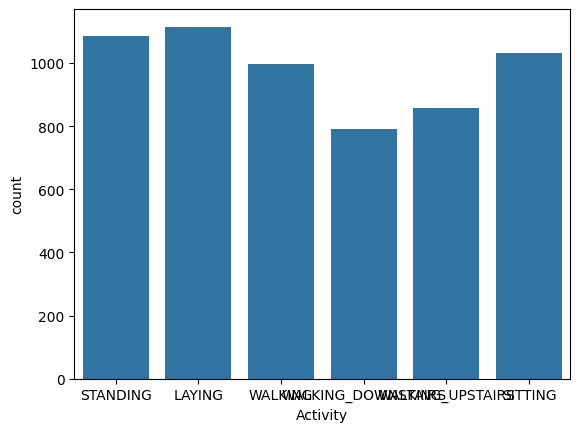

In [ ]:
sns.countplot(x='Activity', data=train_data)

### (3) 센서 그룹 데이터: features X

In [ ]:
feature_data.head()

,sensor,agg,axis,feature_name
0,tBodyAcc,mean(),X,tBodyAcc-mean()-X
1,tBodyAcc,mean(),Y,tBodyAcc-mean()-Y
2,tBodyAcc,mean(),Z,tBodyAcc-mean()-Z
3,tBodyAcc,std(),X,tBodyAcc-std()-X
4,tBodyAcc,std(),Y,tBodyAcc-std()-Y


* **세부 요구사항**
    - feature 이름에 대한 계층 구조별로 변수의 수를 카운트 해 봅시다.
        - sensor 별 변수의 개수
        - agg(regation) 별 변수의 개수
        - axis 별 변수의 개수

In [ ]:
feature_data.value_counts(subset='sensor')

,count
sensor,
fBodyAccJerk,79
fBodyGyro,79
fBodyAcc,79
tBodyAccJerk,40
tGravityAcc,40
tBodyGyroJerk,40
tBodyAcc,40
tBodyGyro,40
tBodyAccMag,13


In [ ]:
feature_data.value_counts(subset='agg')

,count
agg,
bandsEnergy(),126
arCoeff(),60
entropy(),33
energy(),33
min(),33
mean(),33
max(),33
mad(),33
iqr(),33


In [ ]:
feature_data.value_counts(subset='axis')

,count
axis,
Y,76
Z,76
X,76
"X,Z",5
"49,64",5
"57,64",5
"9,16",5
"X,1",5
"X,2",5


## 3.미션1 : 데이터 분석1

수많은 feature들을 모두 살펴보는 것은 과도한 시간과 노력이 필요합니다. 그래서 여러분은 **선택과 집중**을 해야 합니다.
* 1) **트리 모델을 생성**한 후 **변수 중요도**를 구합니다.   
    * random forest 알고리즘 사용을 권장합니다.
* 2) **중요한 feature 상위 N개를 선정**하고, 이들을 대상으로 EDA 수행.
* 3) **각 feature 그룹별 중요도**도 파악해보며 EDA를 수행  
    * Feature 이름에는 계층구조를 담고 있습니다. 그렇다 보니 feature들을 적절하게 그룹으로 묶을 수 있습니다.
    * 참고로, feature 그룹의 중요도는 개별 feature 중요도의 합으로 계산할 수 있습니다.

### (1) 기본모델링 + 변수중요도 추출

* **세부 요구사항**
    - 모델링을 위한 기본 전처리를 수행합니다.
        - 주어진 데이터에서는 x, y로 나누고 train과 validation 분할 수행
    - 트리기반 알고리즘을 이용하여 모델링을 합니다.
        - 랜덤포레스트 권장 : 랜덤포레스트는 튜닝 없이 하이퍼파리미터의 기본값로도 적절한 성능의 모델을 생성할 수 있습니다.
    - 변수 중요도 추출
        - 사용자정의함수로 생성한 plot_feature_importance 을 이용
        - 변수중요도 파악및 결과 저장

#### 1) 데이터 전처리

In [ ]:
target = 'Activity'
x = train_data.drop(columns=target)
y = train_data[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4116, 561), (1765, 561), (4116,), (1765,))

In [ ]:
# PCA 적용
pca = PCA(n_components=0.95)  # 95%의 분산을 유지
pca_train = pca.fit_transform(x_train)
pca_test = pca.transform(x_test)
pca_train_df = pd.DataFrame(data=pca_train)
pca_test_df = pd.DataFrame(data=pca_test)

print(f"Original shape: {x_train.shape}")
print(f"Original shape: {x_test.shape}")
print(f"Reduced shape: {pca_train_df.shape}")
print(f"Reduced shape: {pca_test_df.shape}")

Original shape: (5881, 561)
Original shape: (1471, 561)
Reduced shape: (5881, 67)
Reduced shape: (1471, 67)


In [ ]:
pca_train_df['Activity'] = y_train
pca_test_df['Activity'] = y_test

pca_train_df

,0,1,2,3,4,5,6,7,8,9,...,58,59,60,61,62,63,64,65,66,Activity
0,-4.897537,0.501990,1.828562,-0.266988,-0.143098,0.967964,0.931237,1.139372,0.356686,0.175279,...,0.323062,-0.260142,0.342384,0.242556,-0.070683,0.096060,0.109624,0.078807,-0.150276,STANDING
1,-5.931079,-1.621192,-1.551114,0.621153,-0.243454,-0.468959,0.207434,-1.523001,0.104374,-0.966020,...,-0.226523,-0.259267,0.322073,0.078677,-0.004335,0.340900,-0.192012,-0.137429,-0.267615,LAYING
2,-5.671479,-2.481288,1.994375,0.497383,-0.357457,0.140506,-0.673181,-0.673779,-0.385966,-0.882571,...,-0.071136,-0.400959,0.110505,-0.421049,0.171384,-0.279523,-0.017968,-0.263836,0.026775,STANDING
3,5.526064,0.187776,0.551440,1.273616,-0.654042,0.351024,0.106156,0.633581,-0.222998,0.888948,...,0.378549,0.351068,0.080209,0.065647,-0.107031,0.180780,0.129177,0.003686,-0.296956,WALKING
4,5.640062,1.438823,0.298695,0.370919,1.215981,1.472178,0.380872,-0.656598,0.795815,-1.420241,...,0.234605,0.363049,-0.139023,0.199489,0.308675,0.337179,-0.053603,0.073568,0.274044,WALKING_DOWNSTAIRS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5876,-4.974742,1.286700,1.463334,-0.814350,0.061602,-0.053421,-0.177204,-0.028036,-0.242317,0.015802,...,-0.023965,-0.327422,0.205979,0.098253,-0.139608,-0.319135,-0.088947,0.076534,-0.318700,SITTING
5877,4.745483,1.141113,-0.011039,0.020999,0.702123,-0.157611,-1.682597,-0.715398,0.406419,1.165403,...,0.156243,-0.090460,0.245896,0.065993,0.011467,-0.329960,-0.055493,-0.055352,-0.237301,WALKING_UPSTAIRS
5878,-6.207020,-2.800277,-2.080154,0.551735,-0.880006,0.907782,0.681703,-0.052157,0.136968,0.601546,...,0.333401,0.022523,-0.219027,-0.348740,-0.077571,-0.082726,0.145928,-0.392858,-0.310711,LAYING
5879,5.400099,1.454563,0.163998,1.045647,0.940168,0.884795,-0.060818,0.446376,-0.170670,-0.755993,...,0.017399,0.455460,0.000167,0.144788,-0.267896,0.049640,0.199533,-0.117029,-0.046911,WALKING_UPSTAIRS


#### 2) 모델링

In [ ]:
model = RandomForestClassifier()

model.fit(x_train, y_train)

pred = model.predict(x_test)

In [ ]:
print(classification_report(y_test, pred))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       331
           SITTING       0.94      0.95      0.95       292
          STANDING       0.96      0.95      0.95       331
           WALKING       0.99      0.98      0.99       297
WALKING_DOWNSTAIRS       0.97      0.98      0.98       239
  WALKING_UPSTAIRS       0.97      0.99      0.98       275

          accuracy                           0.97      1765
         macro avg       0.97      0.97      0.97      1765
      weighted avg       0.97      0.97      0.97      1765



In [ ]:
model_pca = RandomForestClassifier()

model_pca.fit(pca_train_df, y_train)

pred_pca = model_pca.predict(pca_test_df)

In [ ]:
print(classification_report(y_test, pred_pca))

                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       292
           SITTING       0.91      0.83      0.87       254
          STANDING       0.87      0.93      0.90       287
           WALKING       0.99      0.98      0.98       228
WALKING_DOWNSTAIRS       0.97      0.99      0.98       195
  WALKING_UPSTAIRS       0.98      0.97      0.97       215

          accuracy                           0.95      1471
         macro avg       0.95      0.95      0.95      1471
      weighted avg       0.95      0.95      0.95      1471



#### 3) 변수 중요도 추출

tGravityAcc : 중력가속도

X축 방향 중력가속도의 최댓값, 평균, 최솟값

Y축 방향 중력가속도의 최댓값

angle(X,gravityMean) : (X축 방향 - 중력가속도 평균) 벡터 사이의 각도

X, Y축 방향 중력가속도가 예측에 비교적 큰 영향을 줌

X, Y축 방향 벡터 사이의 각도 또한 영향이 있음

Laying을 잘 감지하는 것을 확인할 수 있고, 이 때문에 중요도가 높게 나오는 것이라고 판단됨

In [ ]:
feature_importance_df_all = pd.DataFrame({
    'Feature': list(x_train),
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False, ignore_index=True)

feature_importance_df_all.head(20)

,Feature,Importance
0,tGravityAcc-mean()-X,0.033767
1,tGravityAcc-energy()-X,0.031114
2,"angle(X,gravityMean)",0.029923
3,tGravityAcc-mean()-Y,0.029022
4,tGravityAcc-max()-X,0.027552
5,"angle(Y,gravityMean)",0.025842
6,tGravityAcc-min()-Y,0.025770
7,tGravityAcc-max()-Y,0.020655
8,tGravityAcc-min()-X,0.019795
9,"fBodyAccJerk-bandsEnergy()-1,24",0.018356


In [ ]:
pca_fi_all = pd.DataFrame({
    'Feature': list(pca_train_df),
    'Importance': model_pca.feature_importances_
}).sort_values(by='Importance', ascending=False, ignore_index=True)

print(pca_fi_all.head(20))

    Feature  Importance
0         2    0.205471
1         0    0.141736
2         4    0.054032
3         5    0.045393
4         7    0.045150
5         1    0.043620
6         3    0.036083
7         8    0.031142
8         9    0.021604
9        10    0.016259
10       21    0.015513
11        6    0.015490
12       12    0.013756
13       11    0.009179
14       58    0.008543
15       16    0.008395
16       22    0.008375
17       13    0.007959
18       23    0.007740
19       31    0.007563


,feature_name,feature_importance
0,tGravityAcc-max()-X,0.035358
1,tGravityAcc-max()-Y,0.033207
2,tGravityAcc-mean()-X,0.030058
3,tGravityAcc-min()-X,0.027308
4,"angle(X,gravityMean)",0.026324
5,"angle(Y,gravityMean)",0.025938
6,tGravityAcc-energy()-X,0.025557
7,tGravityAcc-min()-Y,0.024689
8,tGravityAcc-mean()-Y,0.020882
9,fBodyAccMag-mad(),0.015959


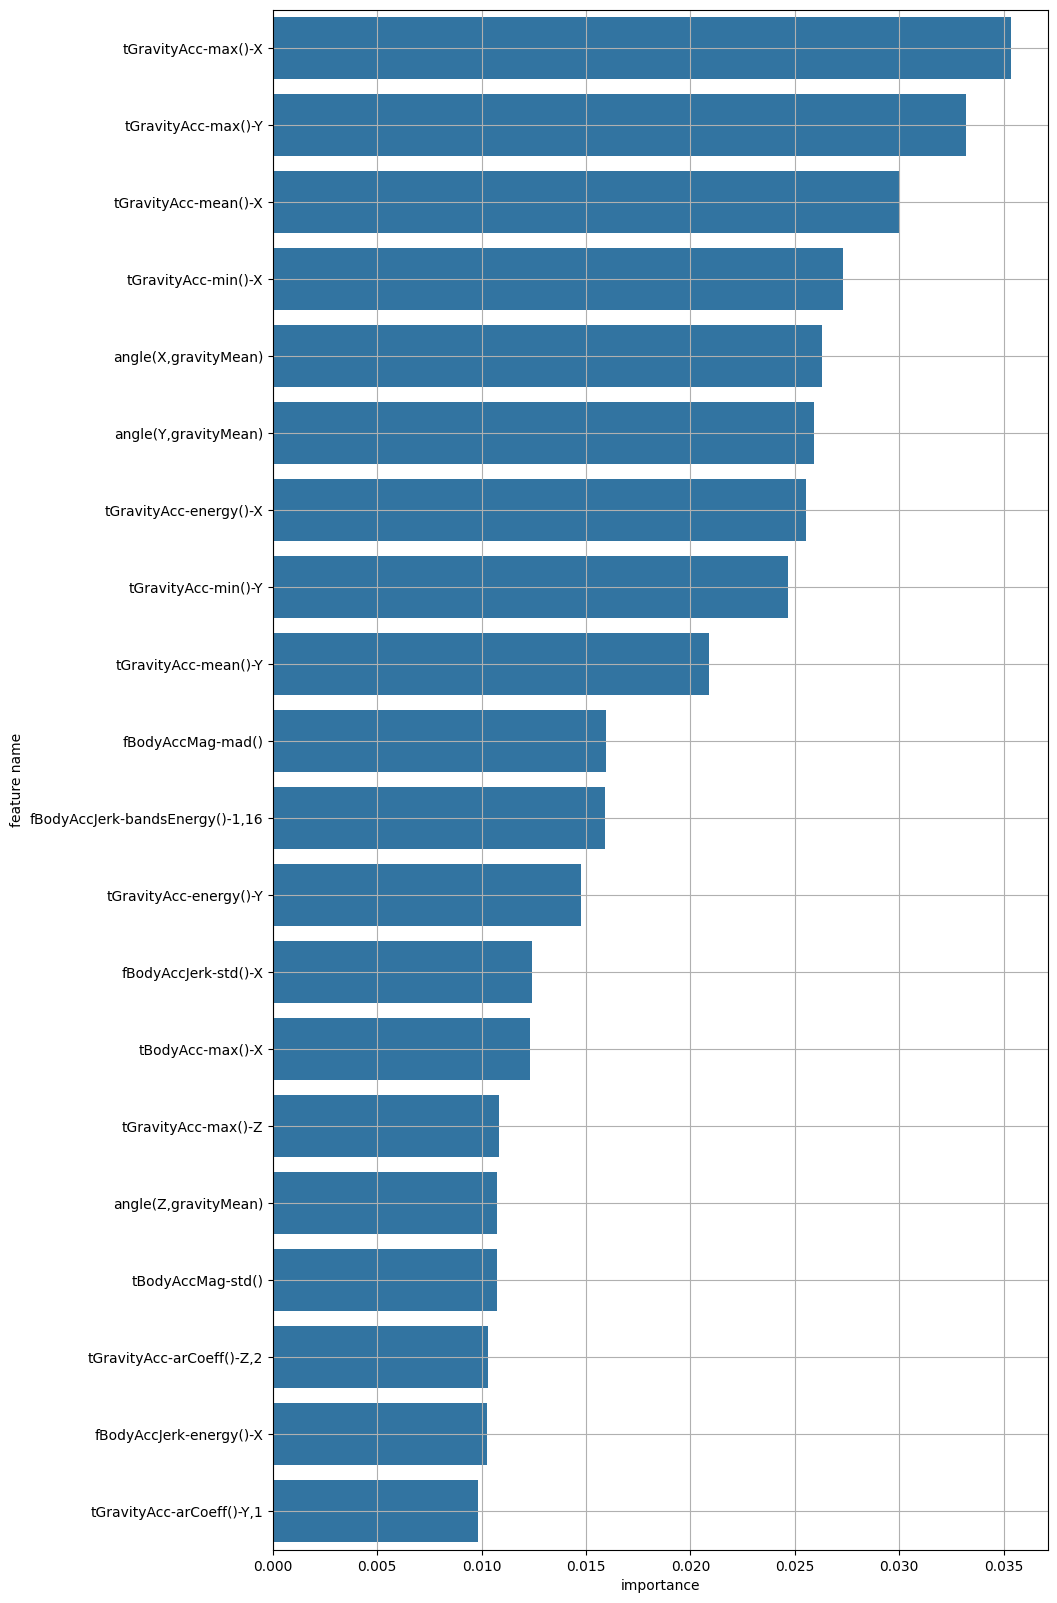

In [ ]:
plot_feature_importance(model.feature_importances_, list(x_train), result_only = False, topn = 20)

### (2) 중요도 기반 feature 분석

* **세부 요구사항**
    - 상위 n, 하위 m 개의 변수를 선정
    - 선정된 변수(feature)와 target 간의 관계를 kdeplot으로 그리기

#### 1) 상위 5, 하위 5개 변수 선정

In [ ]:
top5 = ['tGravityAcc-mean()-X', 'tGravityAcc-energy()-X', 'angle(X,gravityMean)', 'tGravityAcc-mean()-Y', 'tGravityAcc-max()-X']

In [ ]:
min5 = ['fBodyBodyAccJerkMag-entropy()', 'fBodyBodyGyroJerkMag-meanFreq()', 'fBodyAcc-bandsEnergy()-33,48.1', 'tBodyGyroJerk-arCoeff()-Z,2', 'tBodyAccJerkMag-max()']

#### 2) 상위 5개 변수에 대한 분석

<Axes: xlabel='tGravityAcc-mean()-X', ylabel='Density'>

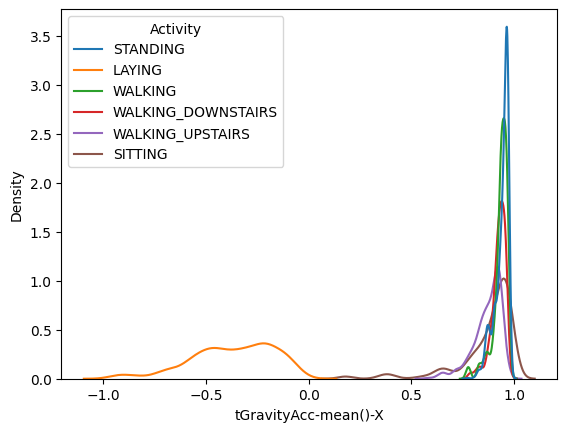

In [ ]:
sns.kdeplot(x=top5[0], hue=target, data=train_data)

<Axes: xlabel='tGravityAcc-energy()-X', ylabel='Density'>

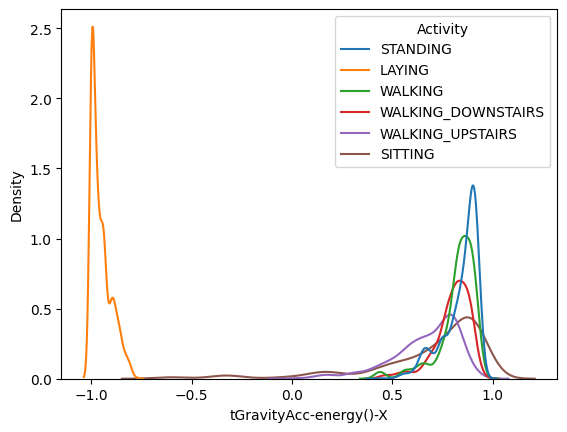

In [ ]:
sns.kdeplot(x=top5[1], hue=target, data=train_data)

<Axes: xlabel='angle(X,gravityMean)', ylabel='Density'>

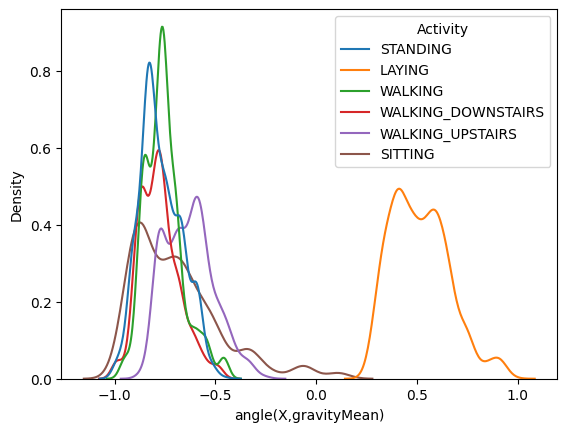

In [ ]:
sns.kdeplot(x=top5[2], hue=target, data=train_data)

<Axes: xlabel='tGravityAcc-mean()-Y', ylabel='Density'>

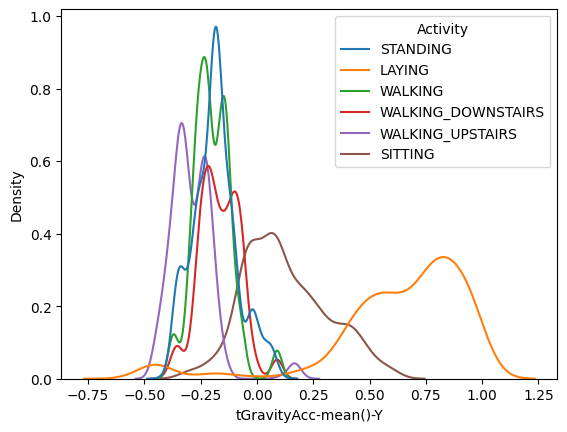

In [ ]:
sns.kdeplot(x=top5[3], hue=target, data=train_data)

<Axes: xlabel='tGravityAcc-max()-X', ylabel='Density'>

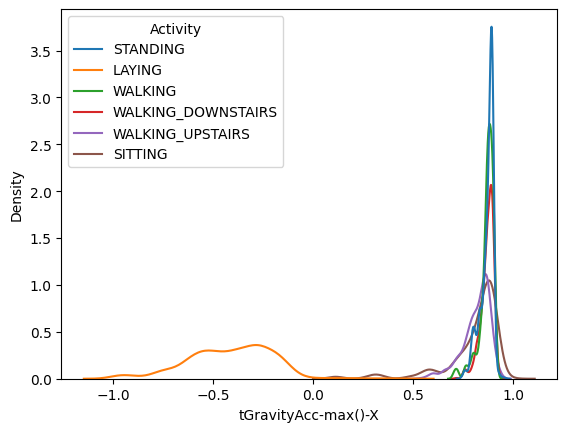

In [ ]:
sns.kdeplot(x=top5[4], hue=target, data=train_data)

<Axes: xlabel='tGravityAcc-max()-Z', ylabel='Density'>

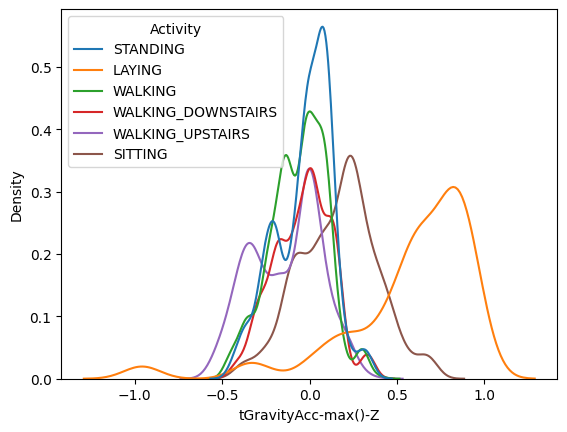

In [ ]:
sns.kdeplot(x='tGravityAcc-max()-Z', hue=target, data=train_data)

<Axes: xlabel='2', ylabel='Density'>

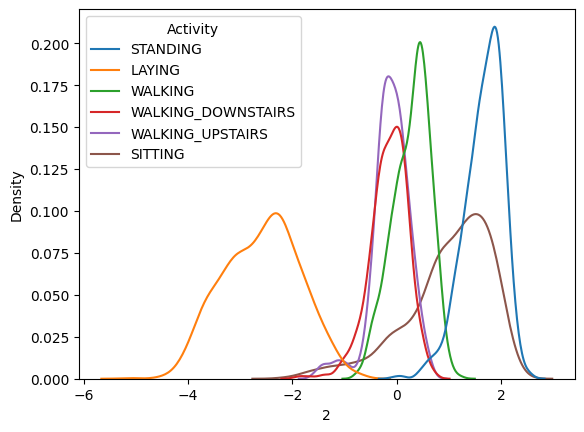

In [ ]:
sns.kdeplot(x=2, hue=target, data=pca_train_df)

#### 3) 하위 5개 변수에 대한 분석

<Axes: xlabel='fBodyBodyAccJerkMag-entropy()', ylabel='Density'>

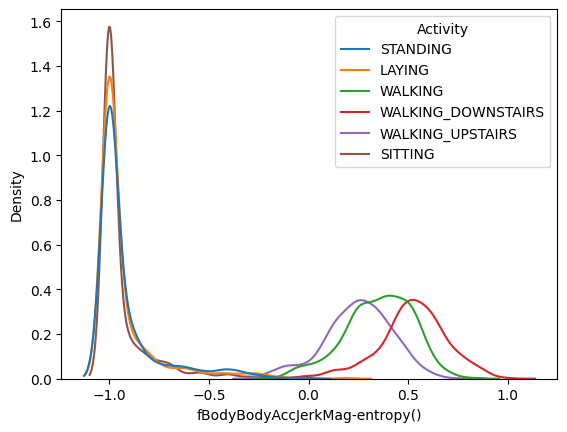

In [ ]:
sns.kdeplot(x=min5[0], hue=target, data=train_data)

<Axes: xlabel='fBodyBodyGyroJerkMag-meanFreq()', ylabel='Density'>

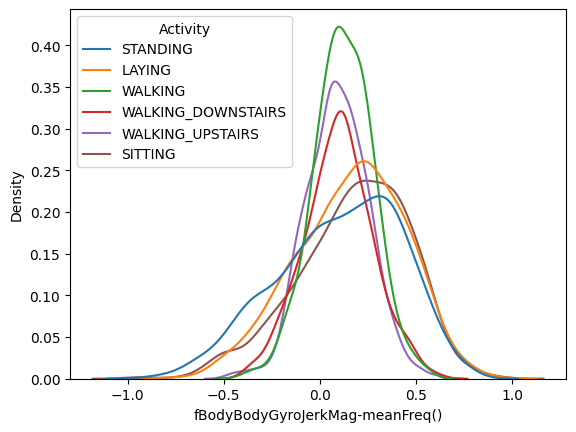

In [ ]:
sns.kdeplot(x=min5[1], hue=target, data=train_data)

<Axes: xlabel='fBodyAcc-bandsEnergy()-33,48.1', ylabel='Density'>

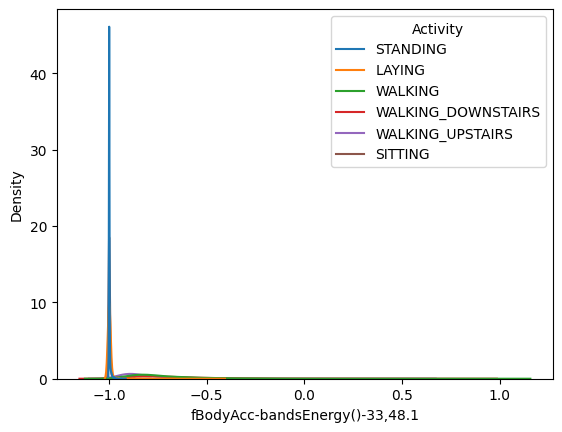

In [ ]:
sns.kdeplot(x=min5[2], hue=target, data=train_data)

<Axes: xlabel='tBodyGyroJerk-arCoeff()-Z,2', ylabel='Density'>

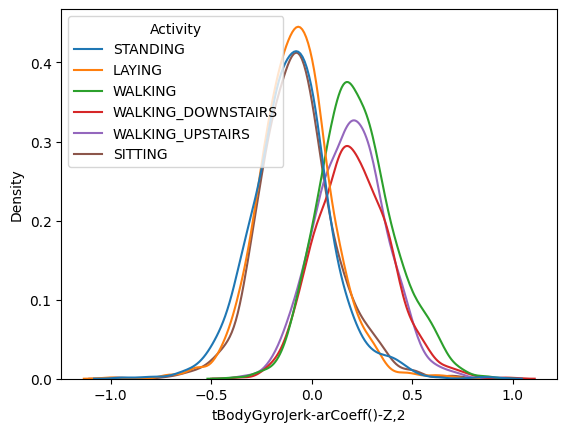

In [ ]:
sns.kdeplot(x=min5[3], hue=target, data=train_data)

<Axes: xlabel='tBodyAccJerkMag-max()', ylabel='Density'>

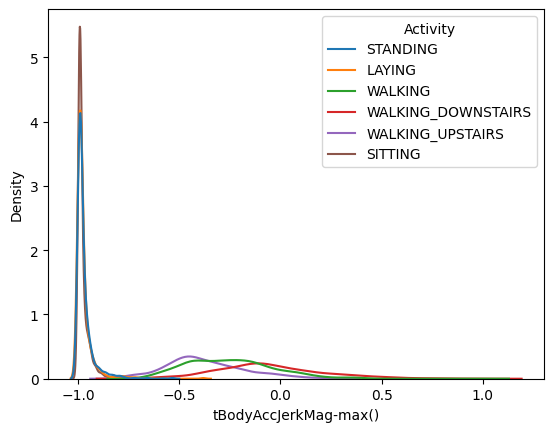

In [ ]:
sns.kdeplot(x=min5[4], hue=target, data=train_data)

## 4.미션2 : 데이터 분석2

다음의 case에 맞게 feature 및 feature 그룹 중요도를 기반으로 탐색적 데이터 분석을 수행하시오.
* Target을 **정적/동적 행동**으로 구분
    * 6개의 행동은 2개의 그룹(정적행동, 동적행동)으로 나뉩니다.  
    * 어떤 feature(혹은 feature 그룹)이 2개 class 그룹(정적행동, 동적행동)를 구분하는데 중요한지를 찾아보고 탐색해봅시다.

### (1) 정적/동적 행동으로 구분하여 분석하기

* **세부 요구사항**
    - Target인 Activity를 is_dynamic 변수로 변경하시오.
        * 값 0 : STANDING, SITTING, LAYING
        * 값 1 : WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS
    - is_dynamic을 예측하기 위한 기본 모델을 생성하시오.
        * x, is_dynamic을 이용하여 train과 validation으로 데이터 분할
        * 기본 모델링
    - is_dynamic 을 구분하는데 중요한 변수 상위 5를 분석하시오.
    - is_dynamic 을 구분하는데 중요한 변수 그룹을 분석하시오.
        * sensor별
        * sensor+agg 별


#### 1) is_dynamic 추가

In [ ]:
y_train_d = pd.Series(np.where(y_train.isin(['STANDING', 'SITTING', 'LAYING']), 0, 1), index=y_train.index)
y_test_d = pd.Series(np.where(y_test.isin(['STANDING', 'SITTING', 'LAYING']), 0, 1), index=y_test.index)

In [ ]:
data_d = train_data.copy()

data_d['is_dynamic'] = np.where(data_d['Activity'].isin(['STANDING', 'SITTING', 'LAYING']), 0, 1)
data_d.drop(columns='Activity', inplace=True)

data_d.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",is_dynamic
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,0
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,0
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,0
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,1
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,1


#### 2) 기본모델 생성

In [ ]:
model_d = RandomForestClassifier()

model_d.fit(x_train, y_train_d)

pred_d = model_d.predict(x_test)

In [ ]:
print(classification_report(y_test_d, pred_d))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       954
           1       1.00      1.00      1.00       811

    accuracy                           1.00      1765
   macro avg       1.00      1.00      1.00      1765
weighted avg       1.00      1.00      1.00      1765



#### 3) 변수중요도 상위 5개 분석

tBodyAccJerk : 가속도변화비율

fBodyAccJerk : 고속퓨리에변환을 거친 가속도변화비율

fBodyAccJerk-bandsEnergy()-1, 16 : 고속퓨리에변환을 거친 1~16 구간의 에너지 밴드 가속도 변화비율

tBodyAccJerkMag-energy() : 유클리드 노름을 사용한 가속도변화비율 3차원 신호 크기 에너지 측정값

가속도변화비율이 큰 영향을 끼치는 이유는 정적 동작일 경우 가속도가 변하지 않는 것이 분명하기 때문이다.

가속도변화비율의 평균, 특히 X축 방향 가속도변화비율이 큰 영향을 끼친다. 동적과 정적을 구분하는 데 X축 방향 움직임의 영향이 크다.

유클리드 노름과 에너지 측정은 다양한 동작을 구분하는 데 중요한 역할을 합니다. 예를 들어:

걷기: 지속적으로 낮은 에너지를 유지하면서 점진적인 가속도가 나타날 수 있습니다.

달리기: 에너지가 높고 빠른 가속도 변화가 있을 것입니다.

정지: 가속도가 거의 0에 가까운 상태를 나타낼 수 있습니다.

In [ ]:
feature_importance_df_ds = pd.DataFrame({
    'Feature': list(x_train),
    'Importance': model_d.feature_importances_
}).sort_values(by='Importance', ascending=False, ignore_index=True)

feature_importance_df_ds.head(20)

,Feature,Importance
0,tBodyAccJerk-mad()-X,0.060029
1,fBodyAccJerk-max()-X,0.060012
2,fBodyAccJerk-entropy()-X,0.050028
3,tBodyAccJerk-std()-X,0.049941
4,"fBodyAccJerk-bandsEnergy()-1,8",0.040049
5,fBodyAccJerk-std()-X,0.040039
6,fBodyAccJerk-mean()-X,0.039980
7,fBodyAccJerk-mad()-X,0.039938
8,"fBodyAcc-bandsEnergy()-9,16",0.039853
9,"fBodyAccJerk-bandsEnergy()-1,24",0.030092


,feature_name,feature_importance
0,"fBodyAccJerk-bandsEnergy()-1,16",0.040233
1,tBodyAccJerk-std()-X,0.040068
2,fBodyAccJerk-std()-X,0.040067
3,tBodyAccJerk-iqr()-X,0.040041
4,tBodyAccJerkMag-energy(),0.039849
5,fBodyAccJerk-entropy()-X,0.029931
6,tBodyAccJerk-entropy()-Y,0.029795
7,tBodyAccJerk-energy()-Y,0.029774
8,tBodyGyroJerkMag-sma(),0.029761
9,fBodyAccJerk-max()-X,0.020086


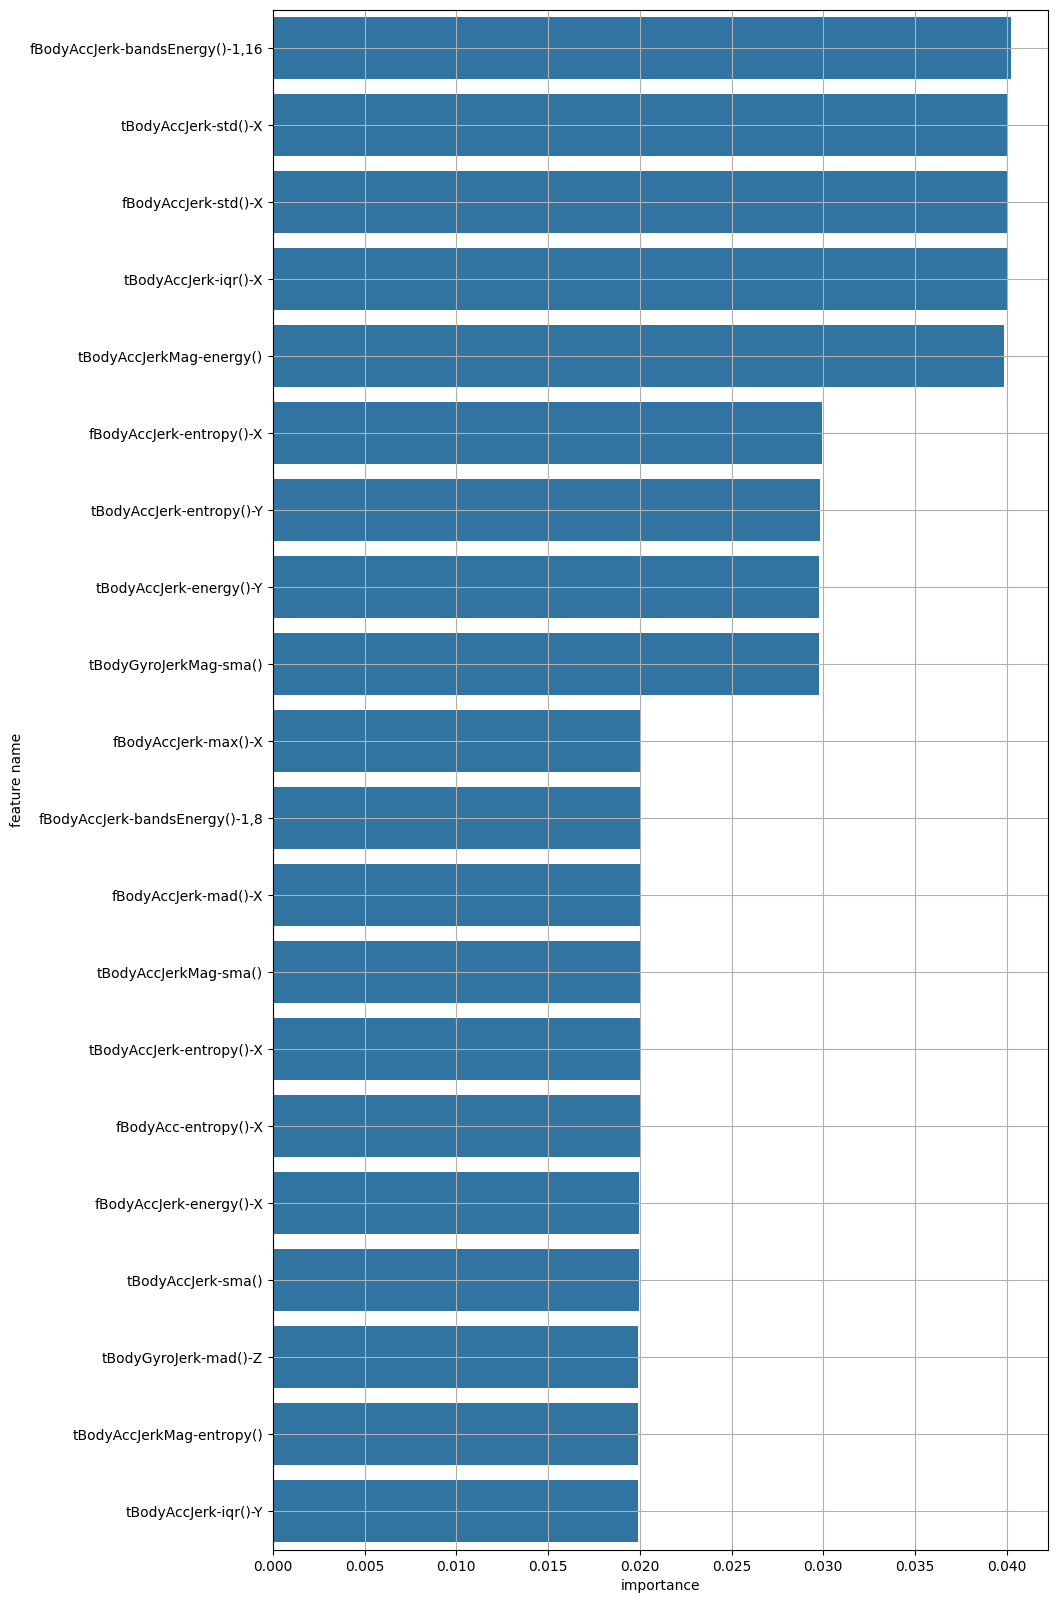

In [ ]:
plot_feature_importance(model_d.feature_importances_, list(x_train), result_only = False, topn = 20)

In [ ]:
top5_d = ['tBodyAccJerk-mad()-X', 'fBodyAccJerk-max()-X', 'fBodyAccJerk-entropy()-X', 'tBodyAccJerk-std()-X', 'fBodyAccJerk-bandsEnergy()-1,8']

<Axes: xlabel='tBodyAccJerk-mad()-X', ylabel='Density'>

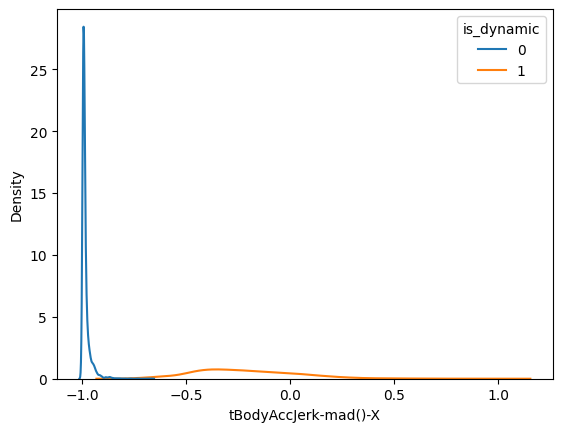

In [ ]:
sns.kdeplot(x=top5_d[0], hue='is_dynamic', data=data_d)

<Axes: xlabel='fBodyAccJerk-max()-X', ylabel='Density'>

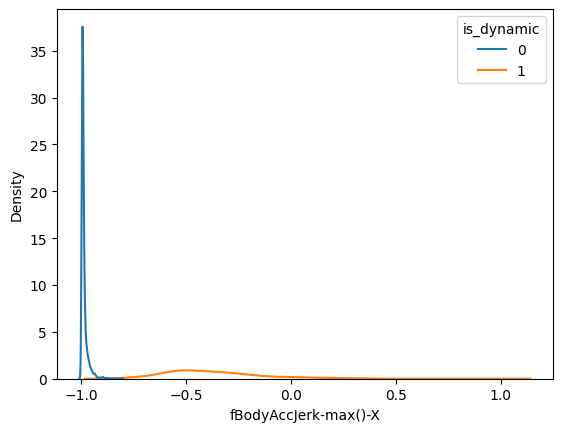

In [ ]:
sns.kdeplot(x=top5_d[1], hue='is_dynamic', data=data_d)

<Axes: xlabel='fBodyAccJerk-entropy()-X', ylabel='Density'>

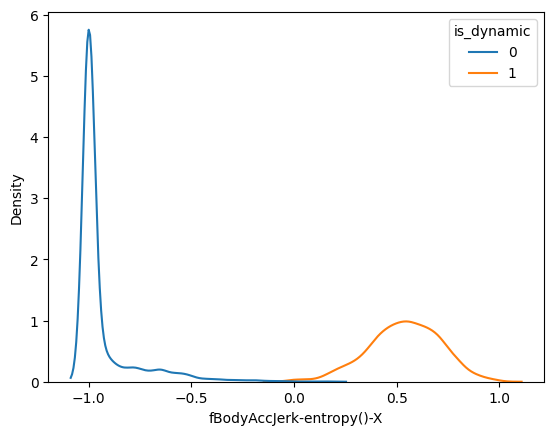

In [ ]:
sns.kdeplot(x=top5_d[2], hue='is_dynamic', data=data_d)

<Axes: xlabel='tBodyAccJerk-std()-X', ylabel='Density'>

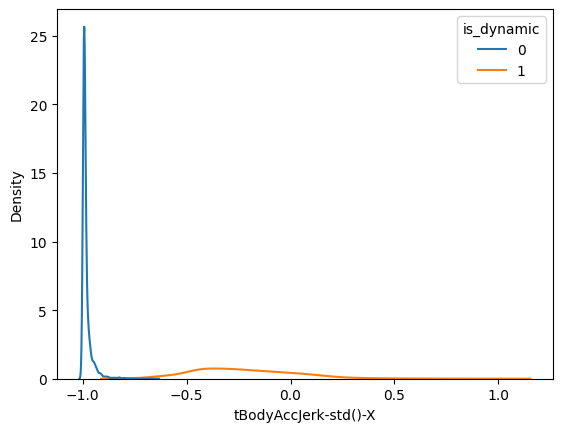

In [ ]:
sns.kdeplot(x=top5_d[3], hue='is_dynamic', data=data_d)

<Axes: xlabel='fBodyAccJerk-bandsEnergy()-1,8', ylabel='Density'>

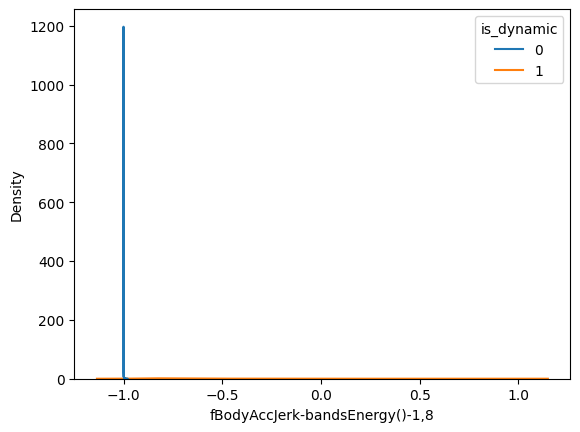

In [ ]:
sns.kdeplot(x=top5_d[4], hue='is_dynamic', data=data_d)

<Axes: xlabel='tBodyAccJerk-std()-X', ylabel='Density'>

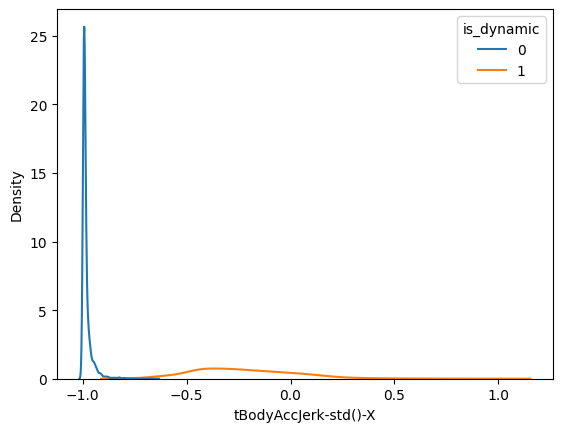

In [ ]:
sns.kdeplot(x='tBodyAccJerk-std()-X', hue='is_dynamic', data=data_d)

세부적인 동작을 예측하기 위해서는 중력가속도가 주로 영향을 끼쳤고 정적 동작과 동적 동작을 구분할 때는 가속도변화비율이 주로 영향을 끼쳤다.

서있기, 앉아있기, 누워있기를 구분할 때 중력가속도가 영향을 준다고 판단할 수 있다.

## 5.특성 중요도 저장하기 X

* **세부 요구사항**
    - 지금까지 변수 중요도를 다양한 관점에서 뽑고 분석을 해 보았습니다.
        - 관점1 : 6개 행동 구분
        - 관점2 : 동적, 정적 행동 구분
    - 모든 관점의 변수 중요도를 하나로 합친 후 저장
        - merge를 이용하여 features와 합칩니다.
        - joblib 패키지의 dump를 이용하여 결과를 저장합니다.

### (1) 하나로 합치기
* 합치기 위해서는 중요도 결과에서 feature_importance 칼럼 이름을 수정해야 합니다.
* pd.merge를 이용해서 하나씩 합치는 작업을 반복 합니다.

#### 1) 이름변경

In [ ]:
feature_importance_df_all.rename(columns={'Importance':'All'}, inplace=True)
feature_importance_df_ds.rename(columns={'Importance':'DS'}, inplace=True)

#### 2) 합치기

In [ ]:
merged_features = pd.merge(feature_importance_df_all, feature_importance_df_ds, on='Feature')

In [ ]:
merged_features.sort_values(by='DS', ascending=False)

,Feature,All,DS
102,tBodyAccJerk-mad()-X,0.002247,0.060029
24,fBodyAccJerk-max()-X,0.008198,0.060012
10,fBodyAccJerk-entropy()-X,0.016315,0.050028
60,tBodyAccJerk-std()-X,0.004395,0.049941
38,"fBodyAccJerk-bandsEnergy()-1,8",0.006321,0.040049
...,...,...,...
233,tBodyAccMag-iqr(),0.000497,0.000000
232,tBodyGyro-min()-Z,0.000498,0.000000
230,fBodyGyro-skewness()-Y,0.000503,0.000000
229,fBodyGyro-skewness()-X,0.000515,0.000000


### (2) 저장하기
* joblib.dump를 이용하시오.
* 저장할 파일의 확장자는 보통 .pkl 입니다.

In [ ]:
joblib.dump(merged_features, 'merged_features.pkl')

['merged_features.pkl']